In [560]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


In [561]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
import Tratar_dados.converter_txt_Lista as cl

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [562]:
arquivo_Gemini_Respostas = r"/workspaces/Sites_Design_Manipulativos/Data/Resultados_Completos/Gemini_respostas_texto.txt"
arquivo_Openai_Respostas = r"/workspaces/Sites_Design_Manipulativos/Data/Resultados_Completos/Openai_respostas_texto.txt"

In [563]:
df_Gemini = cl.converter_Txt(arquivo_Gemini_Respostas).assign(Fonte = 'Gemini')
df_Openai = cl.converter_Txt(arquivo_Openai_Respostas).assign(Fonte = 'Openai')

In [564]:
df_Gemini.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   name                 45 non-null     str  
 1   manipulative_design  45 non-null     bool 
 2   patterns_detected    45 non-null     str  
 3   security_risks       45 non-null     str  
 4   confidence_level     45 non-null     str  
 5   Fonte                45 non-null     str  
dtypes: bool(1), str(5)
memory usage: 1.9 KB


In [565]:
df_Openai.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   name                 45 non-null     str  
 1   manipulative_design  45 non-null     bool 
 2   patterns_detected    45 non-null     str  
 3   security_risks       45 non-null     str  
 4   confidence_level     45 non-null     str  
 5   Fonte                45 non-null     str  
dtypes: bool(1), str(5)
memory usage: 1.9 KB


In [566]:
print(f"Gemini: \n{df_Gemini['manipulative_design'].value_counts()} \n")
print(f"Openai: \n{df_Openai['manipulative_design'].value_counts()}")

Gemini: 
manipulative_design
True     24
False    21
Name: count, dtype: int64 

Openai: 
manipulative_design
True     27
False    18
Name: count, dtype: int64


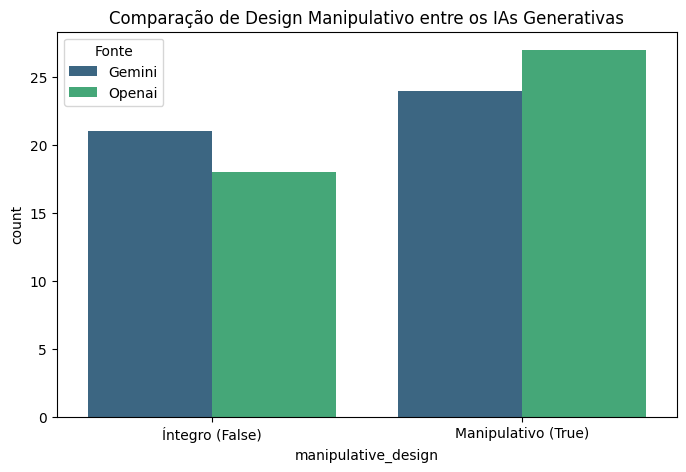

In [567]:
df_final = pd.concat([df_Gemini, df_Openai])

plt.figure(figsize=(8, 5))
sns.countplot(data = df_final, x = 'manipulative_design', hue = 'Fonte', palette = 'viridis')

plt.title("Comparação de Design Manipulativo entre os IAs Generativas")
plt.xticks([0, 1], ['Íntegro (False)', 'Manipulativo (True)'])
plt.show()

In [568]:
df_Gabarito = pd.read_excel(r"/workspaces/Sites_Design_Manipulativos/Data/Gabarito_Resultados.xlsx")
df_Gabarito['name'] = df_Gabarito['name'].apply(lambda url: url if str(url).startswith("https") else "https://" + str(url))

df_Gabarito.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   name                          30 non-null     str  
 1   manipulative_design_Gabarito  30 non-null     bool 
dtypes: bool(1), str(1)
memory usage: 402.0 bytes


In [569]:
i = 0

while i < len(df_Gabarito):
    s1 = df_Openai['name'].iloc[i]
    s2 = df_Gabarito['name'].iloc[i]

    

    if s1 != s2:
        print(f"{s1} compara com {s2}")
        print("As strings são diferentes")


    i += 1

In [570]:
df_Gemini = df_Gemini.merge(
    df_Gabarito[['name', 'manipulative_design_Gabarito']],
    on='name',
    how='left'
)

df_Openai = df_Openai.merge(
    df_Gabarito[['name', 'manipulative_design_Gabarito']],
    on='name',
    how='left'
)

## Performance para as respostas do Gemini

In [572]:
mask_validos_Gemini = df_Gemini['manipulative_design'].notna() & df_Gemini['manipulative_design_Gabarito'].notna()

acertos_Gemini = (df_Gemini.loc[mask_validos_Gemini, 'manipulative_design'] == df_Gemini.loc[mask_validos_Gemini, 
                                                                                             'manipulative_design_Gabarito']).sum()
total_Gemini = mask_validos_Gemini.sum()

proporcao_Gemini = acertos_Gemini / total_Gemini
percentual_Gemini = proporcao_Gemini * 100

if pd.isna(percentual_Gemini):
    percentual_Gemini = 0

print(f"Quantidade de acertos do Gemini {acertos_Gemini}")
print(f"Percentual de acertos do Gemini {percentual_Gemini:.2f}%")

Quantidade de acertos do Gemini 27
Percentual de acertos do Gemini 90.00%


In [573]:
erros_Gemini = total_Gemini - acertos_Gemini

labels_Gemini = ['Acertos', 'Erros']
valores_Gemini = [acertos_Gemini, erros_Gemini]

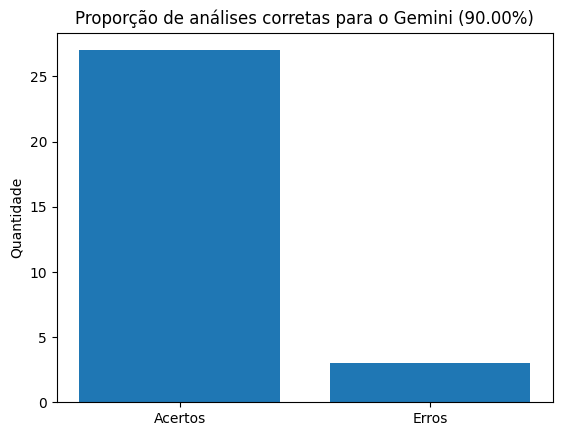

In [574]:
plt.bar(labels_Gemini, valores_Gemini)
plt.title(f'Proporção de análises corretas para o Gemini ({percentual_Gemini:.2f}%)')
plt.ylabel('Quantidade')
plt.show()

## Performance para as respostas do Openai

In [575]:
mask_validos_Openai = df_Openai['manipulative_design'].notna() & df_Openai['manipulative_design_Gabarito'].notna()

acertos_Openai = (df_Openai.loc[mask_validos_Openai, 'manipulative_design'] == df_Openai.loc[mask_validos_Openai, 
                                                                                             'manipulative_design_Gabarito']).sum()
total_Openai = mask_validos_Openai.sum()

proporcao_Openai = acertos_Openai / total_Openai
percentual_Openai = proporcao_Openai * 100

if pd.isna(percentual_Openai):
    percentual_Openai = 0

print(f"Quantidade de acertos do Openai {acertos_Openai}")
print(f"Percentual de acertos do Openai {percentual_Openai:.2f}%")

Quantidade de acertos do Openai 27
Percentual de acertos do Openai 90.00%


In [576]:
erros_Openai = total_Openai - acertos_Openai

labels_Openai = ['Acertos', 'Erros']
valores_Openai = [acertos_Openai, erros_Gemini]

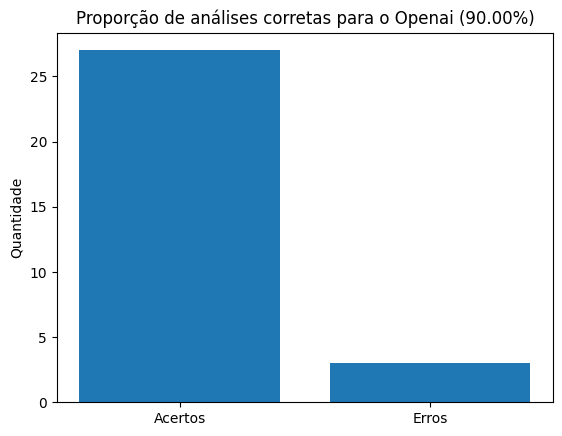

In [577]:
plt.bar(labels_Openai, valores_Openai)
plt.title(f'Proporção de análises corretas para o Openai ({percentual_Openai:.2f}%)')
plt.ylabel('Quantidade')
plt.show()